2025/10/08 10:51:59 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing KNN using PSO...


2025/10/08 10:52:15 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 7.03977 seconds
2025/10/08 10:52:27 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 11.68229 seconds
2025/10/08 10:52:38 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 11.45440 seconds
2025/10/08 10:52:50 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 11.36875 seconds
2025/10/08 10:53:01 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 11.36709 seconds
2025/10/08 10:53:01 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: Base

PSO Accuracy: 0.6228
PSO Best Params: {'n_neighbors': 1, 'weights': 'uniform', 'p': 1}

Optimizing KNN using GA...


2025/10/08 10:53:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 11.58401 seconds
2025/10/08 10:53:36 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 11.62154 seconds
2025/10/08 10:53:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 11.64714 seconds
2025/10/08 10:53:53 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 5.73788 seconds
2025/10/08 10:54:02 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 8.59911 seconds
2025/10/08 10:54:02 PM, INFO, mealpy.swarm_based.BA.OriginalBA: OriginalBA(ep

GA Accuracy: 0.5833
GA Best Params: {'n_neighbors': 3, 'weights': 'uniform', 'p': 1}

Optimizing KNN using Bat...


2025/10/08 10:54:16 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 1.68172 seconds
2025/10/08 10:54:19 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 2.71252 seconds
2025/10/08 10:54:21 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 2.64732 seconds
2025/10/08 10:54:24 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 2.66316 seconds
2025/10/08 10:54:25 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 1.55543 seconds


Bat Accuracy: 0.6228
Bat Best Params: {'n_neighbors': 1, 'weights': 'uniform', 'p': 1}



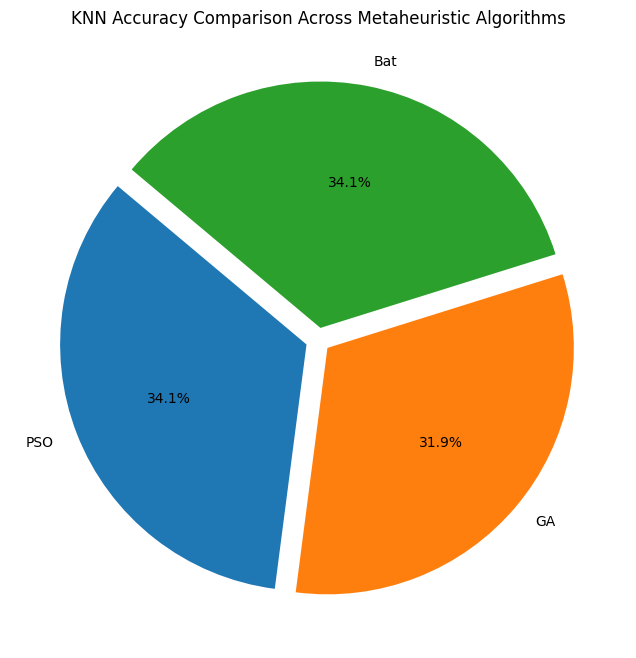

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# KNN Objective Function
# ----------------------------
def knn_objective_function(solution):
    n_neighbors = int(solution[0])
    weights_idx = int(solution[1])
    p = int(solution[2])
    weights = 'uniform' if weights_idx == 0 else 'distance'
    
    try:
        # Ensure n_neighbors is at least 1
        if n_neighbors < 1:
            n_neighbors = 1
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p)
        scores = cross_val_score(knn, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)
    except:
        fitness = 1.0  # Return a high value for invalid parameters
    
    return fitness

# ----------------------------
# KNN Problem Definition
# ----------------------------
knn_problem = {
    "bounds": [
        FloatVar(lb=1, ub=20, name="n_neighbors"),
        FloatVar(lb=0, ub=1, name="weights"),  # 0 = 'uniform', 1 = 'distance'
        FloatVar(lb=1, ub=2, name="p")         # 1 = Manhattan, 2 = Euclidean
    ],
    "minmax": "min",
    "obj_func": knn_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing KNN using {name}...")
    best_agent = optimizer.solve(knn_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    weights = 'uniform' if int(best_solution[1]) == 0 else 'distance'
    p = int(best_solution[2])
    
    best_params = {
        'n_neighbors': int(best_solution[0]),
        'weights': weights,
        'p': p
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("KNN Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()


2025/10/09 12:57:41 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing KNN using PSO...


2025/10/09 12:58:05 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 9.88971 seconds
2025/10/09 12:58:16 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 10.49555 seconds
2025/10/09 12:58:28 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 12.07745 seconds
2025/10/09 12:58:39 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 11.47218 seconds
2025/10/09 12:58:50 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 10.81542 seconds
2025/10/09 12:58:50 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: Base

PSO Accuracy: 0.6228
PSO Best Params: {'n_neighbors': 1, 'weights': 'uniform', 'p': 1}

Optimizing KNN using GA...


2025/10/09 12:59:12 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.5677978316025416, Global best: -0.5677978316025416, Runtime: 10.99688 seconds
2025/10/09 12:59:23 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.5677978316025416, Global best: -0.5677978316025416, Runtime: 10.76099 seconds
2025/10/09 12:59:41 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.5677978316025416, Global best: -0.5677978316025416, Runtime: 17.98351 seconds
2025/10/09 01:00:01 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.5677978316025416, Global best: -0.5677978316025416, Runtime: 20.69020 seconds
2025/10/09 01:00:32 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.5677978316025416, Global best: -0.5677978316025416, Runtime: 30.42355 seconds
2025/10/09 01:00:32 AM, INFO, mealpy.swarm_based.BA.OriginalBA: O

...

Cuckoo Accuracy: 0.6251
Cuckoo Best Params: {'n_neighbors': 3, 'weights': 'uniform', 'p': 2}

Optimizing KNN using Firefly...


2025/10/09 01:10:21 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 1, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 131.68831 seconds
2025/10/09 01:13:03 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 2, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 161.58855 seconds
2025/10/09 01:15:23 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 3, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 140.76108 seconds
2025/10/09 01:17:44 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 4, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 141.11049 seconds
2025/10/09 01:19:56 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 5, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 131.38486 seconds
2025/10/09 01:19:56 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalA

Firefly Accuracy: 0.6228
Firefly Best Params: {'n_neighbors': 1, 'weights': 'uniform', 'p': 1}

Optimizing KNN using ABC...


2025/10/09 01:20:12 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -0.6328559678144811, Global best: -0.6328559678144811, Runtime: 10.63912 seconds
2025/10/09 01:20:23 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -0.6328559678144811, Global best: -0.6328559678144811, Runtime: 10.25347 seconds
2025/10/09 01:20:34 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -0.6328559678144811, Global best: -0.6328559678144811, Runtime: 11.91911 seconds
2025/10/09 01:20:45 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -0.6328559678144811, Global best: -0.6328559678144811, Runtime: 10.26020 seconds
2025/10/09 01:21:00 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -0.6328559678144811, Global best: -0.6328559678144811, Runtime: 15.56813 seconds


ABC Accuracy: 0.6329
ABC Best Params: {'n_neighbors': 1, 'weights': 'uniform', 'p': 2}



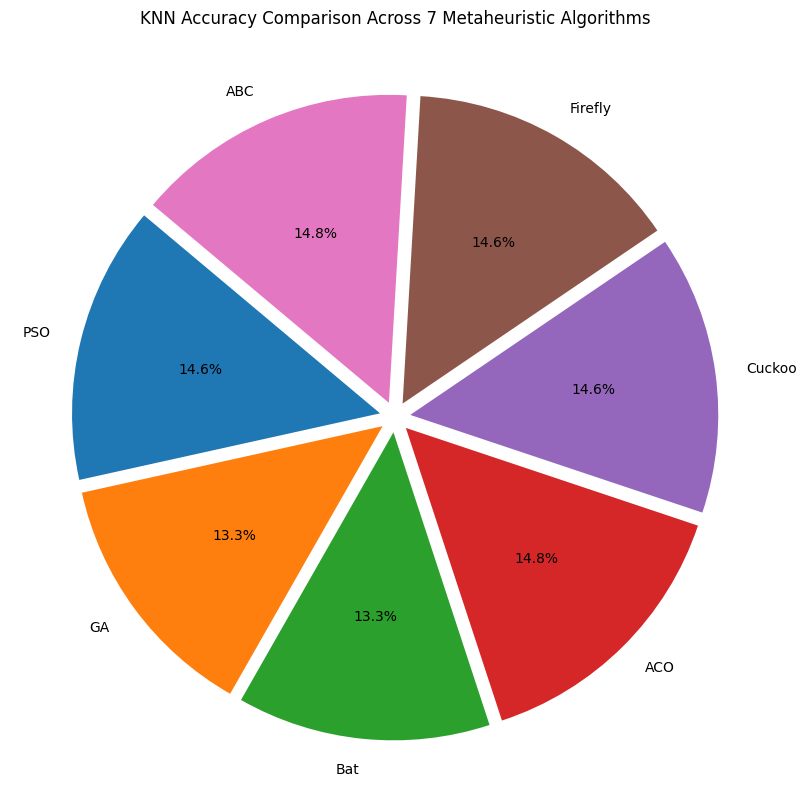

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import warnings

# ----------------------------
# Mealpy algorithm imports (latest structure)
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR  # Correct class name for ACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# KNN Objective Function
# ----------------------------
def knn_objective_function(solution):
    n_neighbors = max(1, int(solution[0]))
    weights_idx = int(solution[1])
    p = int(solution[2])
    weights = 'uniform' if weights_idx == 0 else 'distance'
    
    try:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p)
        scores = cross_val_score(knn, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)
    except:
        fitness = 1.0
    return fitness

# ----------------------------
# KNN Problem Definition
# ----------------------------
knn_problem = {
    "bounds": [
        FloatVar(lb=1, ub=20, name="n_neighbors"),
        FloatVar(lb=0, ub=1, name="weights"),
        FloatVar(lb=1, ub=2, name="p")
    ],
    "minmax": "min",
    "obj_func": knn_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),          # Corrected
    "Cuckoo": CSO.OriginalCSO(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing KNN using {name}...")
    best_agent = optimizer.solve(knn_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    weights = 'uniform' if int(best_solution[1]) == 0 else 'distance'
    p = int(best_solution[2])
    best_params = {
        'n_neighbors': int(best_solution[0]),
        'weights': weights,
        'p': p
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Pie Chart
# ----------------------------
plt.figure(figsize=(10, 10))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("KNN Accuracy Comparison Across 7 Metaheuristic Algorithms")
plt.show()


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025/10/10 06:03:03 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


⚙️ Using device: cpu
✅ Loading cached BERT embeddings from disk...
✅ BERT embeddings ready!

🚀 Optimizing KNN using PSO...


2025/10/10 06:03:54 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 8.07305 seconds
2025/10/10 06:04:03 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 8.28100 seconds
2025/10/10 06:04:11 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 8.56225 seconds
2025/10/10 06:04:20 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 8.60418 seconds
2025/10/10 06:04:28 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 8.52408 seconds
2025/10/10 06:04:28 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(e

✅ PSO Accuracy: 0.8412
🏆 PSO Best Params: {'n_neighbors': 14, 'weights': 'uniform', 'algorithm': 'kd_tree'}


🚀 Optimizing KNN using GA...


2025/10/10 06:04:41 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.8384927823625742, Global best: -0.8384927823625742, Runtime: 5.76879 seconds
2025/10/10 06:04:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.8384927823625742, Global best: -0.8384927823625742, Runtime: 5.58038 seconds
2025/10/10 06:04:52 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.8384927823625742, Global best: -0.8384927823625742, Runtime: 4.81910 seconds
2025/10/10 06:04:55 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.8303004097739409, Global best: -0.8384927823625742, Runtime: 3.44380 seconds
2025/10/10 06:04:58 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.8303004097739409, Global best: -0.8384927823625742, Runtime: 2.69184 seconds
2025/10/10 06:04:58 PM, INFO, mealpy.swarm_based.BA.OriginalBA: Origin

...

✅ Cuckoo Accuracy: 0.8412
🏆 Cuckoo Best Params: {'n_neighbors': 14, 'weights': 'uniform', 'algorithm': 'kd_tree'}


🚀 Optimizing KNN using Firefly...


2025/10/10 06:13:12 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 1, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 107.96246 seconds
2025/10/10 06:14:24 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 2, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 72.46369 seconds
2025/10/10 06:15:48 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 3, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 84.38378 seconds
2025/10/10 06:17:14 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 4, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 85.39934 seconds
2025/10/10 06:18:49 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 5, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 95.06505 seconds
2025/10/10 06:18:49 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalABC(e

✅ Firefly Accuracy: 0.8412
🏆 Firefly Best Params: {'n_neighbors': 14, 'weights': 'uniform', 'algorithm': 'kd_tree'}


🚀 Optimizing KNN using ABC...


2025/10/10 06:19:09 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 12.19903 seconds
2025/10/10 06:19:21 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 12.47331 seconds
2025/10/10 06:19:33 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 11.92907 seconds
2025/10/10 06:19:47 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 14.08711 seconds
2025/10/10 06:19:59 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -0.8412175678462889, Global best: -0.8412175678462889, Runtime: 11.97400 seconds


✅ ABC Accuracy: 0.8412
🏆 ABC Best Params: {'n_neighbors': 14, 'weights': 'uniform', 'algorithm': 'kd_tree'}



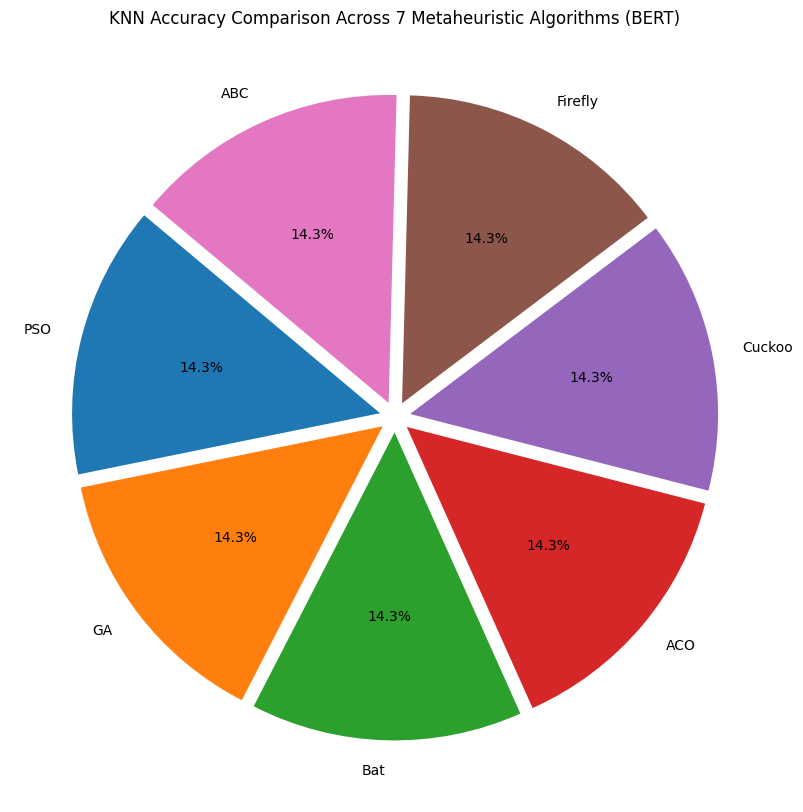

In [1]:
# ===============================================
#   BERT (bert-base-uncased) + Metaheuristic Optimization + KNN
#   (with caching + GPU + Visualization)
# ===============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import warnings
import torch
from transformers import BertTokenizer, BertModel
import os

# ----------------------------
# Mealpy algorithm imports
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')


# ======================================================
# STEP 1: Load dataset + Use BERT for vectorization (with caching)
# ======================================================
def load_data_with_bert(cache_X="bert_base_embeddings.npy", cache_y="bert_base_labels.npy"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"⚙️ Using device: {device}")

    if os.path.exists(cache_X) and os.path.exists(cache_y):
        print("✅ Loading cached BERT embeddings from disk...")
        X = np.load(cache_X)
        y = np.load(cache_y)
    else:
        print("🔄 Generating new BERT embeddings (first run)...")

        # Load datasets
        amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
        imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
        yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
        df = pd.concat([amazon, imdb, yelp], axis=0).reset_index(drop=True)

        # Load BERT tokenizer and model
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        model = BertModel.from_pretrained('bert-base-uncased').to(device)

        def get_bert_embeddings(texts, batch_size=16):
            embeddings = []
            model.eval()
            with torch.no_grad():
                for i in range(0, len(texts), batch_size):
                    batch = texts[i:i+batch_size]
                    encoded = tokenizer(
                        batch, padding=True, truncation=True,
                        max_length=128, return_tensors='pt'
                    ).to(device)

                    outputs = model(**encoded)
                    batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu()
                    embeddings.append(batch_embeddings)
            return torch.cat(embeddings).numpy()

        print("⚙️ Computing embeddings using BERT (this may take several minutes)...")
        X = get_bert_embeddings(df["text"].tolist())
        y = df["label"].values

        # Cache for reuse
        np.save(cache_X, X)
        np.save(cache_y, y)
        print(f"💾 Saved embeddings → {cache_X}, {cache_y}")

    print("✅ BERT embeddings ready!")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test


# ======================================================
# STEP 2: Load Data
# ======================================================
X_train, X_test, y_train, y_test = load_data_with_bert()


# ======================================================
# STEP 3: Objective Function for KNN
# ======================================================
def knn_objective_function(solution):
    n_neighbors = int(solution[0])
    weights_idx = int(solution[1])
    algorithm_idx = int(solution[2])

    weights = 'uniform' if weights_idx == 0 else 'distance'
    algorithms = ['auto', 'ball_tree', 'kd_tree', 'brute']
    algorithm = algorithms[algorithm_idx]

    try:
        knn = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            algorithm=algorithm,
            n_jobs=-1
        )
        scores = cross_val_score(knn, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
        fitness = -np.mean(scores)  # Negative because Mealpy minimizes
    except Exception as e:
        print(f"⚠️ Error: {e}")
        fitness = 1.0
    return fitness


# ======================================================
# STEP 4: Define Optimization Problem
# ======================================================
knn_problem = {
    "bounds": [
        FloatVar(lb=1, ub=15, name="n_neighbors"),
        FloatVar(lb=0, ub=1, name="weights"),         # 0=uniform, 1=distance
        FloatVar(lb=0, ub=3, name="algorithm")        # 0=auto,1=ball_tree,2=kd_tree,3=brute
    ],
    "minmax": "min",
    "obj_func": knn_objective_function
}


# ======================================================
# STEP 5: Run All Metaheuristic Algorithms
# ======================================================
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "Cuckoo": CSO.OriginalCSO(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}
best_params_dict = {}

for name, optimizer in algorithms.items():
    print(f"\n🚀 Optimizing KNN using {name}...")
    best_agent = optimizer.solve(knn_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness  # convert back to accuracy

    weights = 'uniform' if int(best_solution[1]) == 0 else 'distance'
    algorithms_list = ['auto', 'ball_tree', 'kd_tree', 'brute']
    algorithm = algorithms_list[int(best_solution[2])]

    best_params = {
        'n_neighbors': int(best_solution[0]),
        'weights': weights,
        'algorithm': algorithm
    }

    results[name] = best_fitness
    best_params_dict[name] = best_params

    print(f"✅ {name} Accuracy: {best_fitness:.4f}")
    print(f"🏆 {name} Best Params: {best_params}\n")


# ======================================================
# STEP 6: Visualization (Pie Chart)
# ======================================================
plt.figure(figsize=(10, 10))
plt.pie(
    results.values(), labels=results.keys(),
    autopct='%1.1f%%', startangle=140,
    explode=[0.05]*len(results)
)
plt.title("KNN Accuracy Comparison Across 7 Metaheuristic Algorithms (BERT)")
plt.show()
